## Vorbereitung

**Datengrundlage**

Die Analyse basiert auf der bereinigten Tagesdatei `temperatur_bereinigt.csv`:

| Spalte | Bedeutung | Einheit |
|---|---|---|
| `datum` | Datum (YYYY-MM-DD) | – |
| `temperatur_mittel_c` | Tägliches Lufttemperatur-Mittel | °C |

Die Daten sind vollständig bereinigt und auf Tagesebene aggregiert.

## Daten laden

In [2]:
import pandas as pd
import numpy as np

daily_clean = pd.read_csv(
    '/Users/clara/Desktop/uni_dreck/Menden_S26/temperatur_bereinigt.csv',
    parse_dates=['datum'],
    index_col='datum'
)['temperatur_mittel_c'].asfreq('D')

print(f"Zeitraum: {daily_clean.index[0].date()} bis {daily_clean.index[-1].date()}")
print(f"Anzahl Beobachtungen: {len(daily_clean)}")
print(f"Fehlende Tage: {daily_clean.isna().sum()}")

Zeitraum: 1966-01-01 bis 2026-01-11
Anzahl Beobachtungen: 21926
Fehlende Tage: 0


In [3]:
print(daily_clean.describe())

count    21926.000000
mean         9.856622
std          7.657965
min        -18.200000
25%          3.900000
50%         10.000000
75%         15.900000
max         30.300000
Name: temperatur_mittel_c, dtype: float64


## Stationaritätstests 


In [4]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF-Test
result_adf = adfuller(daily_clean, regression='ct', autolag='AIC')

print("ADF-Test (Niveau):")
print(f"  Teststatistik : {result_adf[0]:.4f}")
print(f"  p-Wert        : {result_adf[1]:.4f}")
print(f"  Lags genutzt  : {result_adf[2]}")
print("  Kritische Werte:")
for key, val in result_adf[4].items():
    print(f"    {key}: {val:.4f}")

# KPSS-Test
result_kpss = kpss(daily_clean, regression='ct', nlags='auto')

print("\nKPSS-Test (Niveau):")
print(f"  Teststatistik : {result_kpss[0]:.4f}")
print(f"  p-Wert        : {result_kpss[1]:.4f}")

ADF-Test (Niveau):
  Teststatistik : -11.1171
  p-Wert        : 0.0000
  Lags genutzt  : 47
  Kritische Werte:
    1%: -3.9592
    5%: -3.4107
    10%: -3.1272

KPSS-Test (Niveau):
  Teststatistik : 0.0080
  p-Wert        : 0.1000


/var/folders/fl/yk278gfn3kj475yxzp9ypbrh0000gn/T/ipykernel_6860/913877945.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss = kpss(daily_clean, regression='ct', nlags='auto')


ADF p=0.0000 -> H0 wird abgelehnt, d.h. keine Einheitswurzel laut ADF.
KPSS p=0.1000 -> H0 wird nicht abgelehnt (Teststatistik = 0.0080, Grenze der Tabelle erreicht; tatsächlicher p-Wert liegt über 0.10).

Das Ergebnis ist auf den ersten Blick widersprüchlich: ADF deutet auf Stationarität hin, KPSS ebenfalls. Bei einer Zeitreihe mit starker Saisonalität (Temperaturdaten über 60 Jahre) ist das ADF-Ergebnis auf Niveau durch die hohe Laganzahl (47) beeinflusst. Zur Sicherheit wird dennoch eine erste Differenzierung durchgeführt.

In [5]:
d1 = daily_clean.diff().dropna()

#Tests, aber differenzierte Reihe
result_adf_d1 = adfuller(d1, regression='c', autolag='AIC')
print(f"ADF (1. Diff.): p = {result_adf_d1[1]:.4f}")

result_kpss_d1 = kpss(d1, regression='c', nlags='auto')
print(f"KPSS (1. Diff.): p = {result_kpss_d1[1]:.4f}")

ADF (1. Diff.): p = 0.0000
KPSS (1. Diff.): p = 0.1000


/var/folders/fl/yk278gfn3kj475yxzp9ypbrh0000gn/T/ipykernel_6860/2096797797.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss_d1 = kpss(d1, regression='c', nlags='auto')


ADF (1. Diff.): p = 0.0000 -> H0 abgelehnt, keine Einheitswurzel → stationär.
KPSS (1. Diff.): p = 0.1000 -> H0 nicht abgelehnt → stationär.

Beide Tests bestätigen Stationarität nach einfacher Differenzierung. Die Integrationsordnung ist **d = 1**. Eine zweite Differenzierung ist nicht nötig.

## ACF & PACF

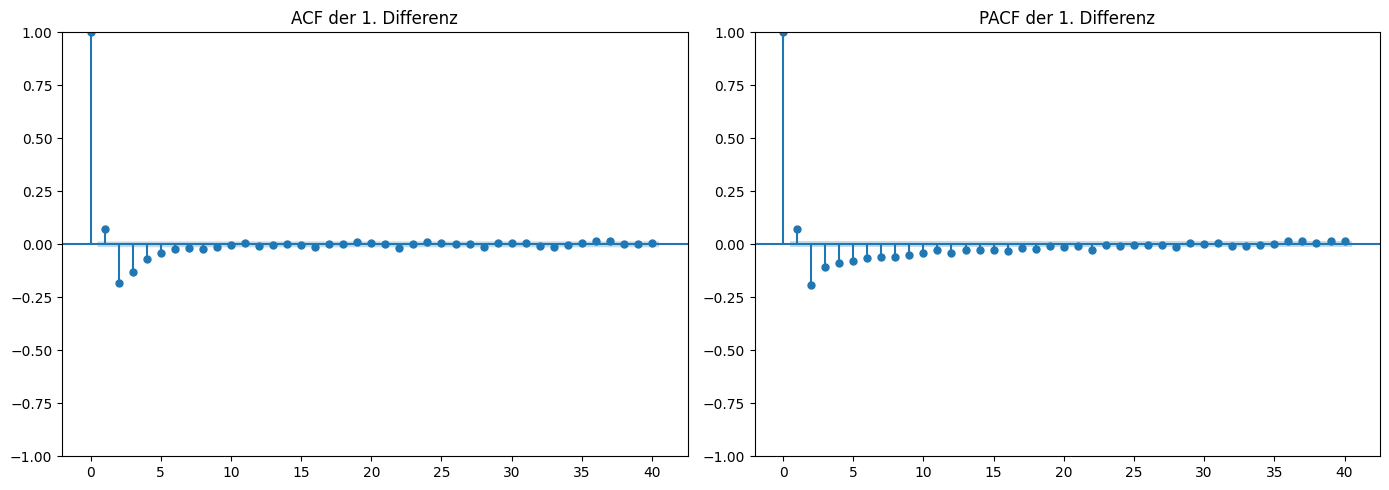

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(d1,  lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF der 1. Differenz')

plot_pacf(d1, lags=40, ax=axes[1], method='ywm', alpha=0.05)
axes[1].set_title('PACF der 1. Differenz')

plt.tight_layout()
plt.show()

**Interpretation** 

Was man siehst:
Der blaue Balken bei Lag 0 ist immer 1.0 –> normal, jede Reihe korreliert perfekt mit sich selbst
Das hellblaue Band ist das 95%-Konfidenzintervall – Balken die außerhalb liegen sind statistisch signifikant
Lag 2 ragt in beiden Plots deutlich nach unten heraus – das ist das einzige klar signifikante Signal


ACF:
Nur Lag 2 signifikant, danach alles innerhalb des Bandes
Kein langsames Abklingen → kein Trend mehr vorhanden (das zeigt dass die Differenzierung funktioniert hat)
Ein einzelner signifikanter Lag deutet auf eine MA-Komponente hin → q = 2 als Kandidat 

PACF:
Sieht fast identisch aus wie die ACF
Auch nur Lag 2 signifikant
Deutet auf eine AR-Komponente hin → p = 1 oder 2 als Kandidat

Schlussfolgerung: 
Das Muster ist nicht ganz eindeutig – beide Plots sehen ähnlich aus, was typisch für ein ARMA-Mischmodell ist. Das spricht für kleine Werte von p und q.

## Modelselektion

In [7]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

rows = []

for p in range(0, 6):      # AR-Ordnung
    for q in range(0, 6):  # MA-Ordnung
        try:
            m = ARIMA(daily_clean, order=(p, 1, q)).fit()
            rows.append({
                'p': p, 'q': q,
                'AIC': m.aic,
                'BIC': m.bic,
                'LogL': m.llf
            })
        except Exception:
            pass  # Manche Kombinationen konvergieren nicht

rdf = pd.DataFrame(rows)

print("Top 5 nach AIC:")
print(rdf.sort_values('AIC').head(5).to_string(index=False))

print("\nTop 5 nach BIC:")
print(rdf.sort_values('BIC').head(5).to_string(index=False))

Top 5 nach AIC:
 p  q          AIC          BIC          LogL
 4  2 96778.567906 96834.535586 -48382.283953
 2  5 96778.907606 96842.870668 -48381.453803
 3  1 96779.693136 96819.670050 -48384.846568
 5  2 96780.470313 96844.433375 -48382.235156
 4  3 96780.624435 96844.587497 -48382.312217

Top 5 nach BIC:
 p  q          AIC          BIC          LogL
 1  2 96784.211874 96816.193405 -48388.105937
 3  1 96779.693136 96819.670050 -48384.846568
 1  3 96781.288427 96821.265341 -48385.644214
 2  2 96781.854853 96821.831767 -48385.927427
 1  4 96781.450876 96829.423173 -48384.725438


AIC vs. BIC: Beide bestrafen Modellkomplexität (BIC stärker). AIC wählt deshalb oft komplexere Modelle, BIC einfachere. Für Prognose und Interpretierbarkeit ist das sparsamste gut spezifizierte Modell (BIC-Kriterium) meist besser.

AIC-Sieger: ARIMA(4,1,2) mit AIC=96778.57 – 6 Parameter.
BIC-Sieger: ARIMA(1,1,2) mit BIC=96816.19 – 3 Parameter.

Bei 21926 Beobachtungen bestraft das BIC Komplexität deutlich stärker. ARIMA(1,1,2) liefert mit nur 3 Parametern einen BIC-Wert, der alle komplexeren Modelle klar schlägt. Die kleinen p- und q-Werte passen zudem zum ACF/PACF-Befund. → Gewähltes Modell: **ARIMA(1,1,2)**.

## Model schätzen

In [8]:
model = ARIMA(daily_clean, order=(1, 1, 2)).fit()
print(model.summary())

                                SARIMAX Results                                
Dep. Variable:     temperatur_mittel_c   No. Observations:                21926
Model:                  ARIMA(1, 1, 2)   Log Likelihood              -48388.106
Date:                 Sat, 16 May 2026   AIC                          96784.212
Time:                         16:45:10   BIC                          96816.193
Sample:                     01-01-1966   HQIC                         96794.629
                          - 01-11-2026                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6274      0.011     55.030      0.000       0.605       0.650
ma.L1         -0.6082      0.012    -51.169      0.000      -0.632      -0.585
ma.L2         -0.2486      0.007    -35.052 

**Fazit:**
1. ACF/PACF: Lag 2 ragt in beiden Plots signifikant heraus, danach liegen alle Werte im Konfidenzband. Das deutet auf ein Modell mit kleinen p- und q-Werten hin.
2. AIC/BIC: Die Gridsuche über p,q ∈ {0,...,5} ergibt ARIMA(1,1,2) als BIC-Sieger (BIC=96816.19). Das Parsimonieprinzip wird bevorzugt – bei 21926 Datenpunkten ist ein Modell mit 3 Parametern klar ausreichend. Die kleinen p- und q-Werte passen zum ACF/PACF-Ergebnis.

**Koeffizienten:**
- ar.L1 = 0.6274 (z = 55.03, p < 0.001) → hoch signifikant → gestrige Temperaturveränderung beeinflusst die heutige
- ma.L1 = −0.6082 (z = −51.17, p < 0.001) → hoch signifikant → Fehler von gestern wird korrigiert
- ma.L2 = −0.2486 (z = −35.05, p < 0.001) → signifikant → Fehler von vorgestern hat noch Einfluss

Alle |z| >> 1.96 → alle Koeffizienten auf 1%-Niveau signifikant → kein Parameter überflüssig.

## Residualdiagnostik

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_arch

resid = model.resid.dropna()

# Ljung-Box: Test auf Autokorrelation in den Residuen
# H0: keine Autokorrelation bis Lag k
lb = acorr_ljungbox(resid, lags=[10, 20, 30], return_df=True)
print(lb)

# Jarque-Bera: Test auf Normalverteilung
# H0: Residuen sind normalverteilt
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(resid)
print(f"JB: Stat={jb_stat:.2f}, p={jb_p:.4f}")
print(f"Schiefe={jb_skew:.3f}, Kurtosis={jb_kurt:.3f}")

# Heteroskedastizitätstest
# H0: keine Heteroskedastizität
arch_stat, arch_p, _, _ = het_arch(resid)
print(f"ARCH-Test: Stat={arch_stat:.4f}, p={arch_p:.4f}")

      lb_stat  lb_pvalue
10  10.073185   0.434096
20  19.353475   0.498968
30  42.928183   0.059455
JB: Stat=662.52, p=0.0000
Schiefe=-0.140, Kurtosis=3.804
ARCH-Test: Stat=250.4780, p=0.0000


**Interpretation:**

Ljung-Box: p = 0.43 (Lag 10), 0.50 (Lag 20), 0.059 (Lag 30) → alle p > 0.05 → Residuen zeigen keine signifikante Autokorrelation → Modell ist gut spezifiziert.

Jarque-Bera: Stat = 662.52, p = 0.0000 → H0 (Normalverteilung) wird abgelehnt.
Kurtosis = 3.80 → leicht fettere Ränder als Normalverteilung – bei 60 Jahren Wetterdaten mit Extremereignissen akzeptabel.
Schiefe = −0.14 → nahezu symmetrisch → gut.

ARCH-Test: Stat = 250.48, p = 0.0000 → Heteroskedastizität vorhanden. Die Varianz der Residuen ist nicht konstant, was bei Temperaturdaten mit ausgeprägter Saisonalität (höhere Varianz im Winter, geringere im Sommer) zu erwarten ist. Für eine reine Punktprognose ist ARIMA dennoch geeignet; für Konfidenzintervalle sollte die Heteroskedastizität beachtet werden.

**t-Statistik Fazit:**
ar.L1: z = 55.03 → hoch signifikant → gestrige Temperaturveränderung beeinflusst die heutige stark
ma.L1: z = −51.17 → hoch signifikant → Prognosefehler von gestern wird systematisch korrigiert
ma.L2: z = −35.05 → hoch signifikant → Fehler von vorgestern hat noch messbaren Einfluss

Alle |z| >> 1.96 → alle Koeffizienten auf 1%-Niveau signifikant → kein Parameter überflüssig.

## Prognose

In [10]:
forecast = model.get_forecast(steps=10)

# Punktprognose
fc_mean = forecast.predicted_mean

# Konfidenzintervall (alpha=0.05 -> 95%-Kontingenzintervall)
fc_ci = forecast.conf_int(alpha=0.05)

result = pd.concat([fc_mean.rename('Prognose'), fc_ci], axis=1)
result.columns = ['Prognose', 'KI_unten', 'KI_oben']
print(result.round(2))

            Prognose  KI_unten  KI_oben
2026-01-12     -4.95     -9.26    -0.64
2026-01-13     -4.00    -10.15     2.16
2026-01-14     -3.39    -10.41     3.62
2026-01-15     -3.02    -10.55     4.51
2026-01-16     -2.78    -10.66     5.10
2026-01-17     -2.63    -10.79     5.52
2026-01-18     -2.54    -10.92     5.84
2026-01-19     -2.48    -11.05     6.09
2026-01-20     -2.44    -11.20     6.31
2026-01-21     -2.42    -11.34     6.50
